# Hyperparameter Tuning

## Objective

- Understand the concept of hyperparameter tuning.
- Learn the difference between parameters and hyperparameters.
- Implement Grid Search and Random Search using Scikit-learn.
- Compare baseline and tuned model performance.
- Evaluate the impact of hyperparameter optimization.

# Dataset Information

**Dataset Name:** Wine Quality Dataset

**Kaggle Link:**
https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

**Reason for Selection:**
This real-world dataset contains physicochemical properties of wines and their quality ratings. It is suitable for demonstrating hyperparameter tuning using classification algorithms.

**Target Variable:** `quality`

**Credits:** Kaggle

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("dataset/wineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## Dataset Exploration

Before tuning the model, we explore the dataset structure, target distribution, and identify missing values.

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nWine Quality Distribution:")
print(df['quality'].value_counts().sort_index())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())

Dataset Shape: (1143, 13)

Column Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

Wine Quality Distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Summary Statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


## Data Preprocessing

The `Id` column is removed because it does not contribute to prediction. The dataset is divided into features and target variables. The data is then split into training and testing sets.

In [4]:
# Remove unnecessary column
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# Features
X = df.drop('quality', axis=1)

# Target
y = df['quality']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

print("\nQuality Distribution:")
print(y.value_counts().sort_index())

Training Feature Shape: (914, 11)
Testing Feature Shape: (229, 11)
Training Target Shape: (914,)
Testing Target Shape: (229,)

Quality Distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


## Baseline Model

Before tuning hyperparameters, we train a baseline Random Forest Classifier using default settings. This provides a reference point for measuring improvements after optimization.

In [5]:
# Baseline Model
baseline_model = RandomForestClassifier(
    random_state=42
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_predictions = baseline_model.predict(
    X_test
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(
    "Baseline Accuracy:",
    round(baseline_accuracy, 4)
)

Baseline Accuracy: 0.7162


## Grid Search

Grid Search evaluates every possible combination of specified hyperparameter values to identify the best-performing model configuration.

In [6]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print(
    "Best Parameters (Grid Search):"
)

print(
    grid_search.best_params_
)

print(
    "\nBest Cross Validation Score:",
    round(grid_search.best_score_, 4)
)

Best Parameters (Grid Search):
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation Score: 0.6532


## Random Search

Random Search samples a fixed number of random hyperparameter combinations, making it computationally more efficient than exhaustive Grid Search.

In [7]:
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train,
    y_train
)

print(
    "Best Parameters (Random Search):"
)

print(
    random_search.best_params_
)

print(
    "\nBest Cross Validation Score:",
    round(random_search.best_score_, 4)
)

Best Parameters (Random Search):
{'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 30}

Best Cross Validation Score: 0.6532


## Tuned Model Evaluation

The best model obtained from Grid Search is evaluated on the test dataset.

In [8]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Tuned Model Accuracy:",
    round(accuracy, 4)
)

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Tuned Model Accuracy: 0.7162

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.74      0.85      0.79        97
           6       0.69      0.74      0.71        92
           7       0.74      0.48      0.58        29
           8       0.00      0.00      0.00         3

    accuracy                           0.72       229
   macro avg       0.36      0.34      0.35       229
weighted avg       0.68      0.72      0.69       229



c:\Users\harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

## Confusion Matrix

The confusion matrix summarizes the classification performance of the tuned model across different wine quality categories.

In [9]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(
    "Confusion Matrix:"
)

print(cm)

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  0  4  3  0  0]
 [ 0  0 82 14  1  0]
 [ 0  0 21 68  3  0]
 [ 0  0  3 12 14  0]
 [ 0  0  0  2  1  0]]


## Wine Quality Distribution

This visualization shows the distribution of wine quality ratings present in the dataset.

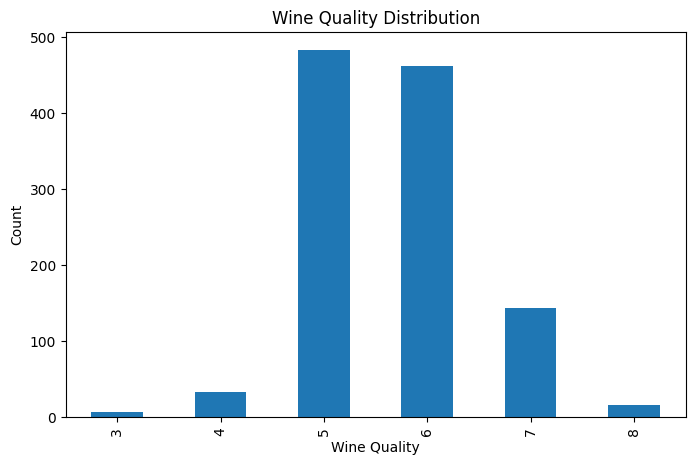

In [10]:
plt.figure(figsize=(8, 5))

df['quality'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title(
    'Wine Quality Distribution'
)

plt.xlabel(
    'Wine Quality'
)

plt.ylabel(
    'Count'
)

plt.show()

## Model Comparison

The table below compares the performance of the baseline model and the tuned model obtained through Grid Search.

In [11]:
comparison = pd.DataFrame({
    'Model': [
        'Baseline Random Forest',
        'Tuned Random Forest'
    ],
    'Accuracy': [
        baseline_accuracy,
        accuracy
    ]
})

comparison

,Model,Accuracy
0,Baseline Random Forest,0.716157
1,Tuned Random Forest,0.716157


## Interview Corner

### Question:
Why is hyperparameter tuning important?

### Answer:
Hyperparameter tuning helps identify the best configuration for a machine learning model, improving its predictive performance and generalization ability. Proper tuning can significantly enhance accuracy without changing the underlying algorithm.

## Hyperparameter Tuning Equation

### Total Grid Search Combinations

Total Combinations = n₁ × n₂ × n₃ × ... × nₖ

Where:

- n₁, n₂, ..., nₖ represent the number of candidate values specified for each hyperparameter.
- k represents the number of hyperparameters.

### Significance

The equation helps estimate the computational cost associated with exhaustive Grid Search.

## Key Takeaways

1. Hyperparameters are configuration settings defined before model training.
2. Grid Search evaluates every possible combination of specified hyperparameter values.
3. Random Search explores a subset of combinations, reducing computational cost.
4. Cross Validation provides reliable estimates of model performance.
5. Baseline models help quantify improvements achieved through tuning.
6. Choosing appropriate evaluation metrics is essential for meaningful optimization.
7. Hyperparameter tuning can significantly improve predictive performance without changing the algorithm.

## Workflow Diagram

![Hyperparameter Tuning Workflow](images/workflow.png)